<a href="https://colab.research.google.com/github/kamalahmadov474/Machine_Learning/blob/main/SpaceX_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/Spacex.csv')

# Display basic info
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Date               101 non-null    object
 1   Time (UTC)         101 non-null    object
 2   Booster_Version    101 non-null    object
 3   Launch_Site        101 non-null    object
 4   Payload            101 non-null    object
 5   PAYLOAD_MASS__KG_  101 non-null    int64 
 6   Orbit              101 non-null    object
 7   Customer           101 non-null    object
 8   Mission_Outcome    101 non-null    object
 9   Landing _Outcome   101 non-null    object
dtypes: int64(1), object(9)
memory usage: 8.0+ KB
None
         Date Time (UTC) Booster_Version  Launch_Site  \
0  04-06-2010   18:45:00  F9 v1.0  B0003  CCAFS LC-40   
1  08-12-2010   15:43:00  F9 v1.0  B0004  CCAFS LC-40   
2  22-05-2012   07:44:00  F9 v1.0  B0005  CCAFS LC-40   
3  08-10-2012   00:35:00  F9 v1.0  B0006  CCAFS 

In [3]:
# Drop duplicates or irrelevant columns if needed
df = df.drop_duplicates()

# Check for missing values
print(df.isnull().sum())

# Drop or fill missing values
df = df.dropna()  # or use df.fillna(method='ffill'), depending on your analysis


Date                 0
Time (UTC)           0
Booster_Version      0
Launch_Site          0
Payload              0
PAYLOAD_MASS__KG_    0
Orbit                0
Customer             0
Mission_Outcome      0
Landing _Outcome     0
dtype: int64


In [4]:
from sklearn.preprocessing import LabelEncoder

# Encode all object-type columns
label_encoders = {}
for column in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le


In [5]:
# Separate features and target
# Example: Let's assume target is 'Mission_Outcome' (replace with the correct column name)
X = df.drop('Mission_Outcome', axis=1)  # replace with actual target column
y = df['Mission_Outcome']


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

svm_model = SVC(kernel='linear')  # You can try 'rbf' or 'poly' as well
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = svm_model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9047619047619048
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.95      0.95      0.95        20
           2       0.00      0.00      0.00         0

    accuracy                           0.90        21
   macro avg       0.32      0.32      0.32        21
weighted avg       0.90      0.90      0.90        21



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

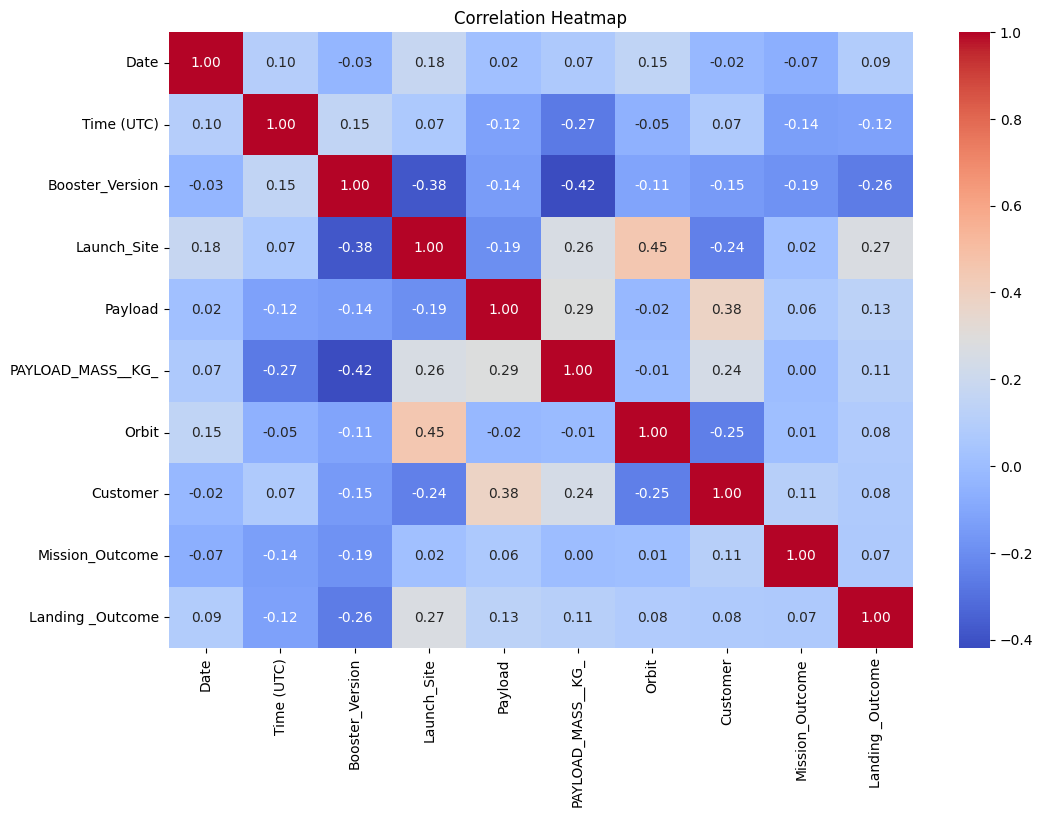

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


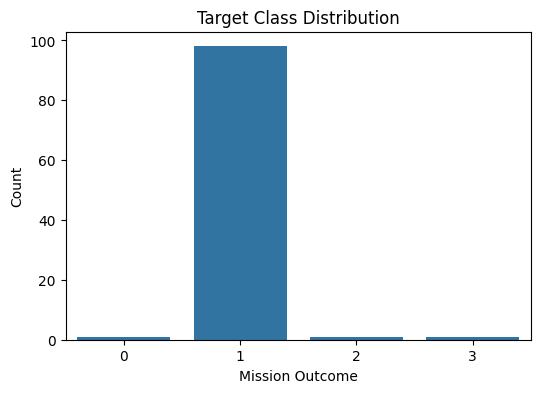

In [10]:
# Distribution of target classes
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Mission_Outcome')
plt.title('Target Class Distribution')
plt.xlabel('Mission Outcome')
plt.ylabel('Count')
plt.show()
